In [67]:
import re
import csv


data = {}

with open('FTE_results.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_mask(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            
            # 2. Parse the data line into a list of floats
            values = [float(x) if x else 0.0 for x in lines[k+1].strip().split(',')]
            
            # 3. Build the nested dictionary structure
            if i_idx not in data:
                data[i_idx] = {}
            
            data[i_idx][j_idx] = values

# --- Usage Example ---
# To get IC index 1, Mask index 5:
example_data = data[1][5]


Text(0.5, 1.0, 'old 4V Model')

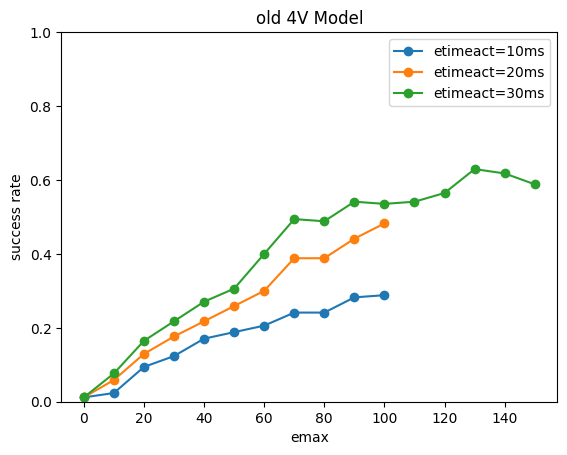

In [109]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict
data2 = {}

with open('FTE_results_test_multiple_IC(1).csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_mask(\d+)_Emax(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            e_idx = int(match.group(3))
            
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else 0.0 for x in lines[k+1].strip().split(',')]
            
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            data2[i_idx][j_idx][e_idx] = values
success_rate_10 = defaultdict(lambda: defaultdict(float))
for E_max_idx in sorted(data2[1][1].keys()):
    for IC_idx in data2.keys():
        for mask_idx in data2[IC_idx].keys():
            
            if len(data2[IC_idx][mask_idx][E_max_idx]) <= 500/dt:
                success_rate_10[E_max_idx][IC_idx] += 1.0 / (len(data2[IC_idx].keys() )*len(data2.keys()))
data2 = {}
with open('FTE_results_test_multiple_IC_20etime.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_mask(\d+)_Emax(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            e_idx = int(match.group(3))
            
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else 0.0 for x in lines[k+1].strip().split(',')]
            
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            data2[i_idx][j_idx][e_idx] = values
success_rate = defaultdict(lambda: defaultdict(float))
for E_max_idx in sorted(data2[1][1].keys()):
    for IC_idx in data2.keys():
        for mask_idx in data2[IC_idx].keys():
            
            if len(data2[IC_idx][mask_idx][E_max_idx]) <= 500/dt:
                success_rate[E_max_idx][IC_idx] += 1.0 / (len(data2[IC_idx].keys() )*len(data2.keys()))
                
data2 = {}
with open('FTE_results_etimeact_30.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_mask(\d+)_Emax(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            e_idx = int(match.group(3))
            
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else 0.0 for x in lines[k+1].strip().split(',')]
            
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            data2[i_idx][j_idx][e_idx] = values
success_rate30 = defaultdict(lambda: defaultdict(float))
for E_max_idx in sorted(data2[1][1].keys()):
    for IC_idx in data2.keys():
        for mask_idx in data2[IC_idx].keys():
            
            if len(data2[IC_idx][mask_idx][E_max_idx]) <= 500/dt:
                success_rate30[E_max_idx][IC_idx] += 1.0 / (len(data2[IC_idx].keys() )*len(data2.keys()))

plt.plot(sorted(success_rate_10.keys()), [sum([i for i in success_rate_10[e_idx].values()]) for e_idx in sorted(success_rate_10.keys())],'-o', label='etimeact=10ms')
plt.plot(sorted(success_rate.keys()), [sum([i for i in success_rate[e_idx].values()]) for e_idx in sorted(success_rate.keys())],'-o', label='etimeact=20ms')
plt.plot(sorted(success_rate30.keys()), [sum([i for i in success_rate30[e_idx].values()]) for e_idx in sorted(success_rate30.keys())],'-o', label='etimeact=30ms')
plt.ylim(0,1)
plt.legend()
plt.xlabel('emax')
plt.ylabel('success rate')
plt.savefig('success_rate_vs_emax_etimeact.png')
plt.title('old 4V Model')

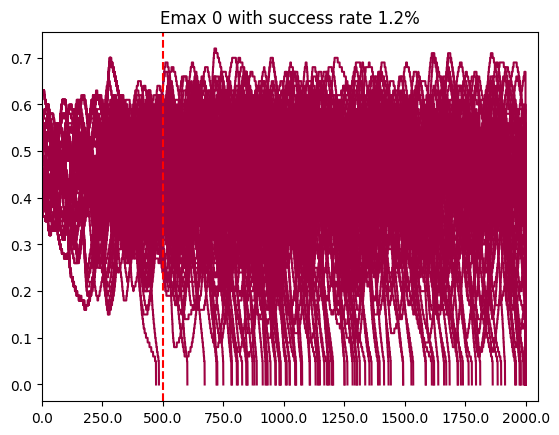

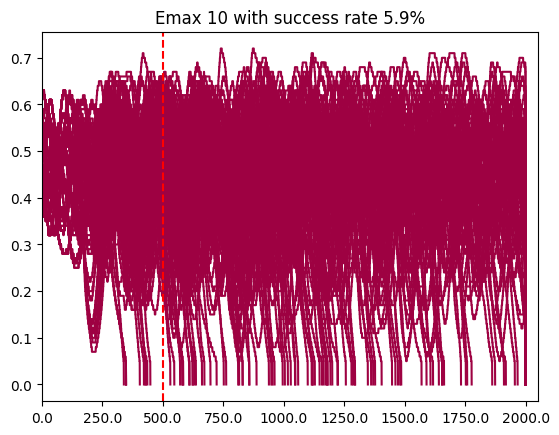

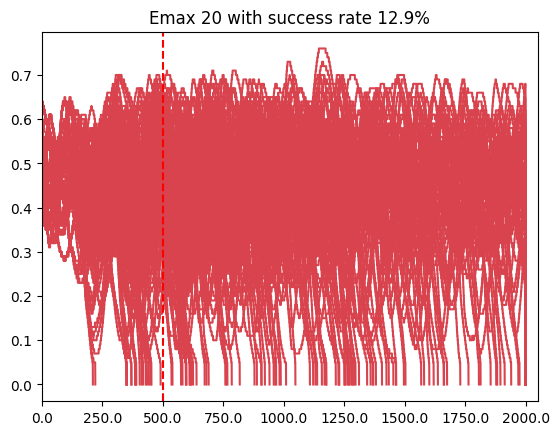

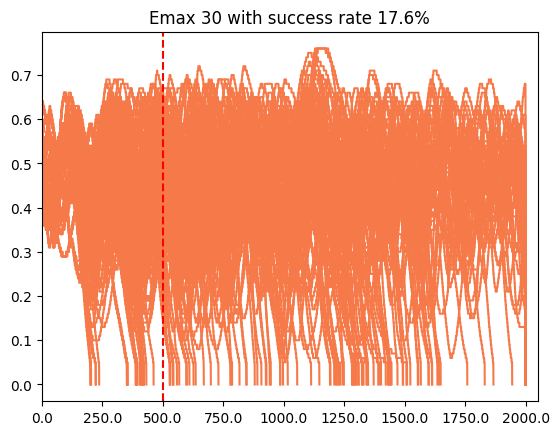

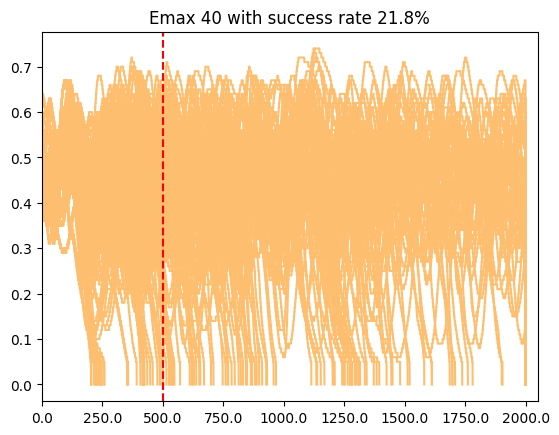

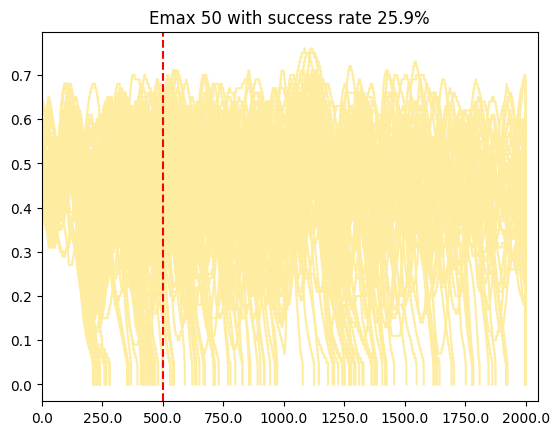

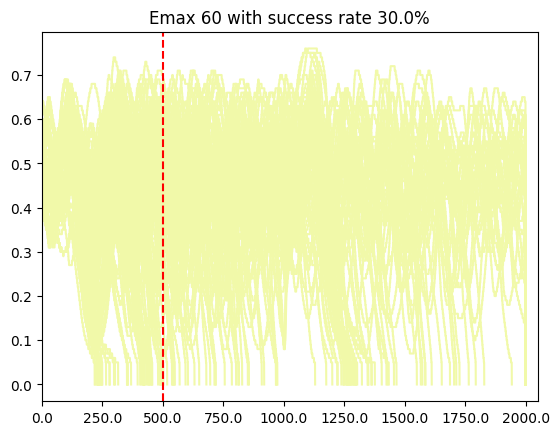

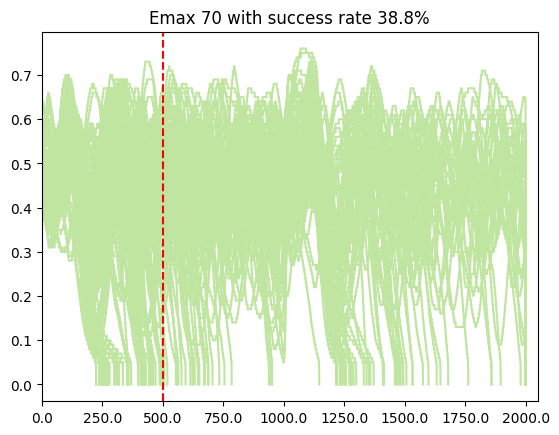

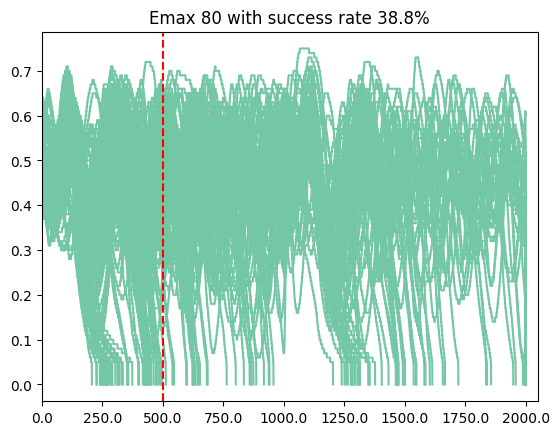

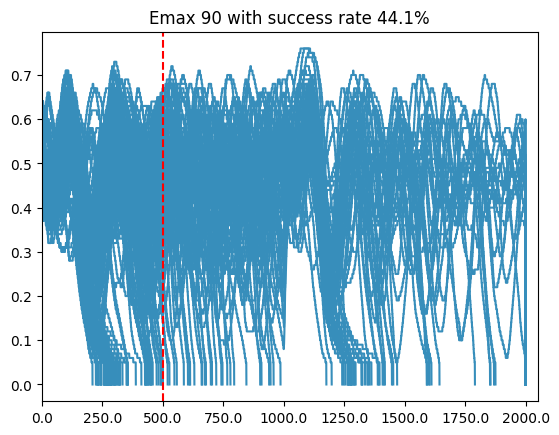

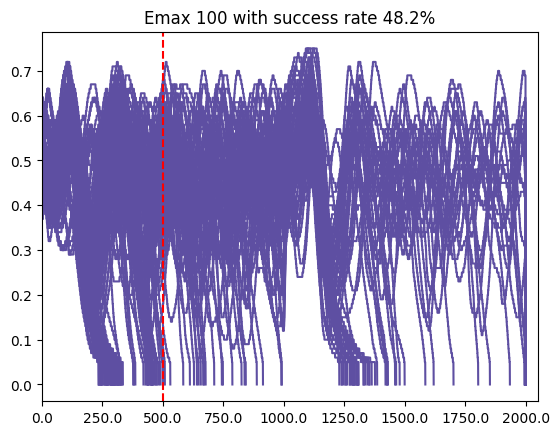

In [99]:
dt = 0.5
# make color based on Emax (Emax 20,60,100)
def get_color_gradient(val, vmin=10, vmax=100):
    # 1. Normalize the value to a 0.0 - 1.0 range
    normalized = (val - vmin) / (vmax - vmin)
    
    # 2. Get the color from a colormap (e.g., 'plasma', 'viridis', 'inferno')
    colormap = plt.get_cmap('Spectral')
    return colormap(normalized)

success_rate = defaultdict(lambda: defaultdict(float))
for E_max_idx in sorted(data2[1][1].keys()):
    plt.figure()
    for IC_idx in data2.keys():
        for mask_idx in data2[IC_idx].keys():
            
            if len(data2[IC_idx][mask_idx][E_max_idx]) <= 500/dt:
                success_rate[E_max_idx][IC_idx] += 1.0 / (len(data2[IC_idx].keys() )*len(data2.keys()))
            plt.plot(data2[IC_idx][mask_idx][E_max_idx],color = get_color_gradient(E_max_idx))
            # make sure x range from 0 to 4000
            plt.xlim(0,4100)
            # also make x tick *= 0.5
            plt.xticks(ticks=range(0,4001,500), labels=[str(x*0.5) for x in range(0,4001,500)])
    plt.title(f'Emax {E_max_idx} with success rate {sum([i for i in success_rate[E_max_idx].values()])*100:.1f}%')

    # plot the success rate metric as a vertical line
    plt.axvline(x=500/dt, color='r', linestyle='--', label='Success Threshold (500s)')

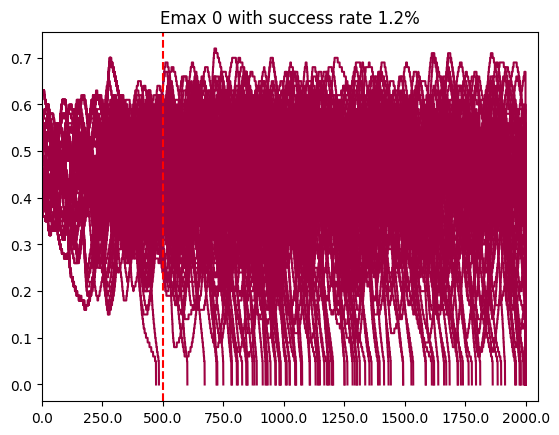

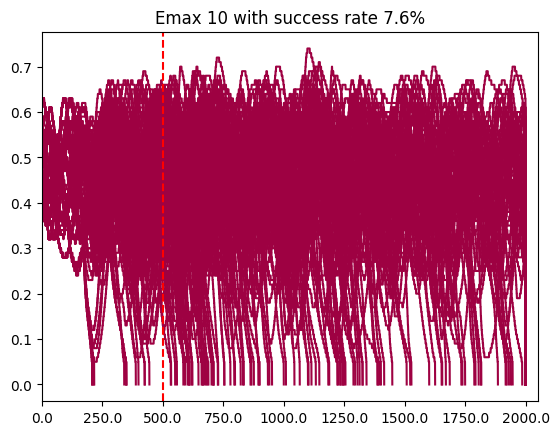

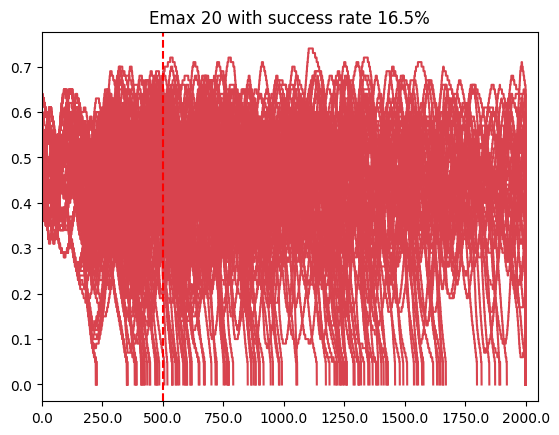

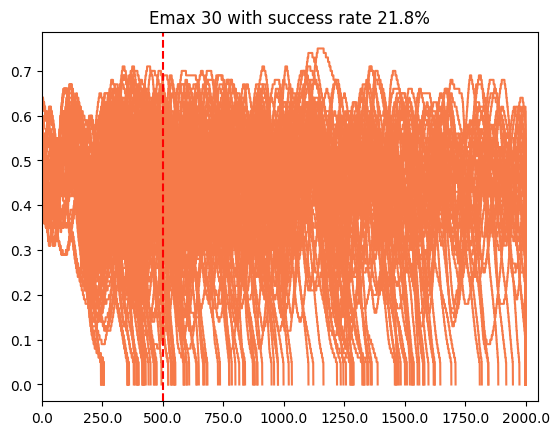

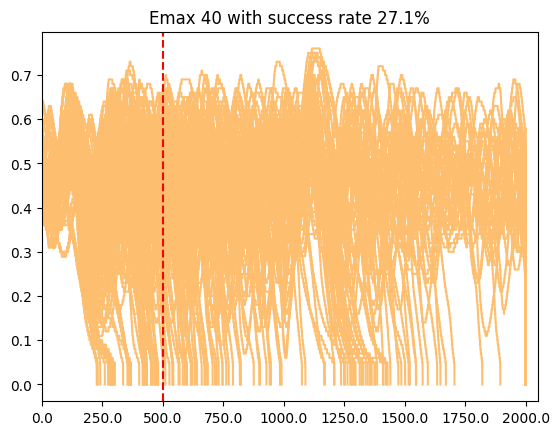

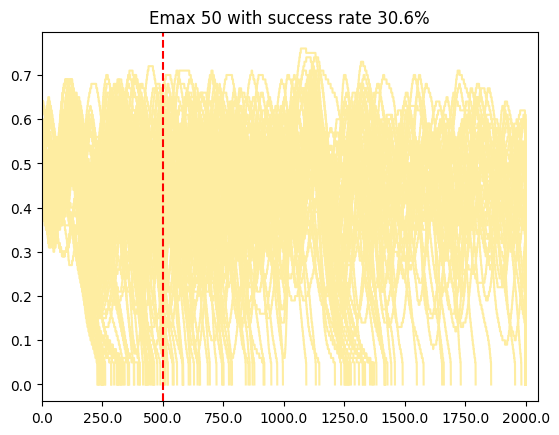

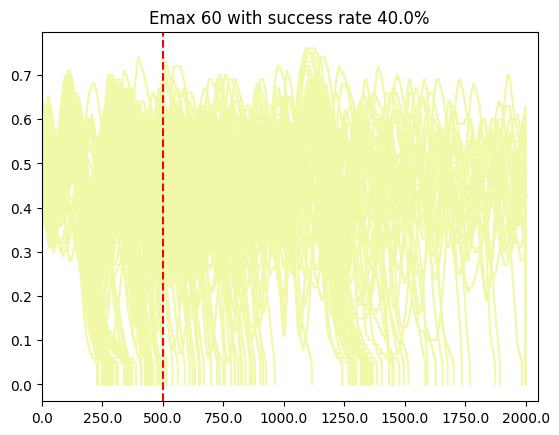

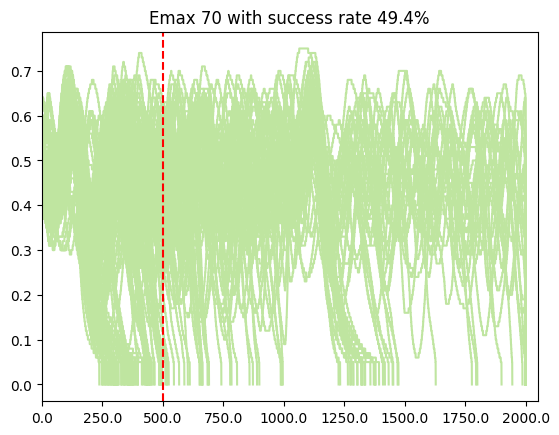

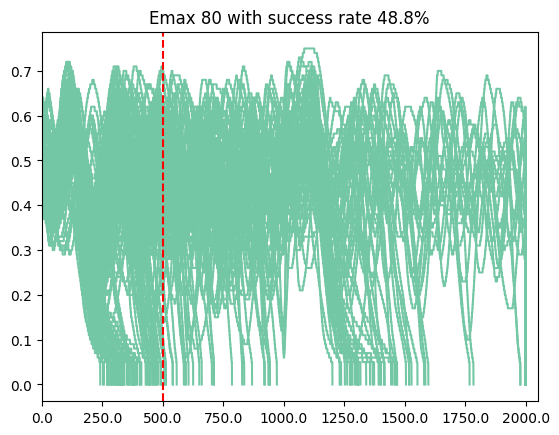

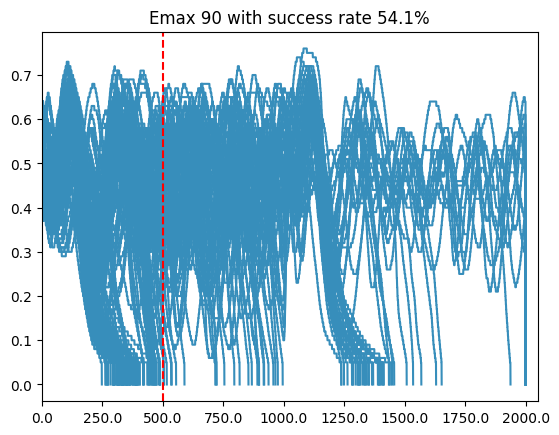

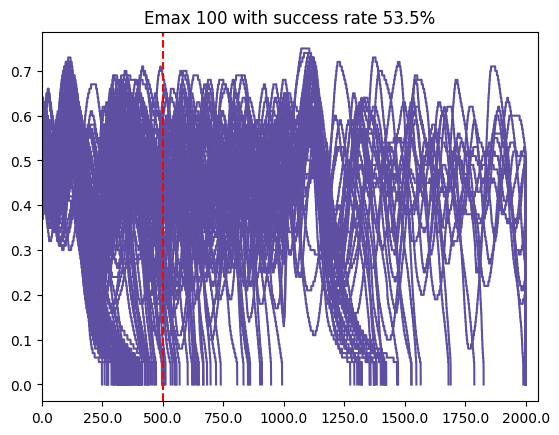

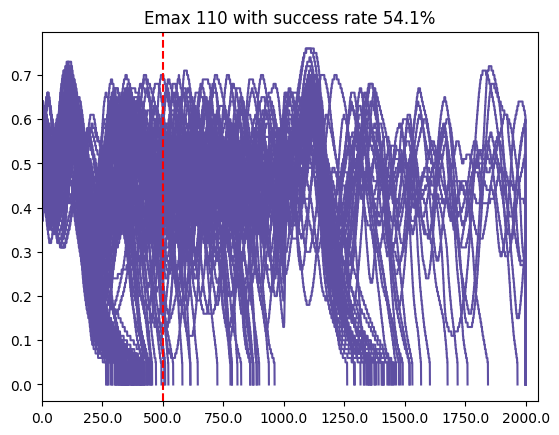

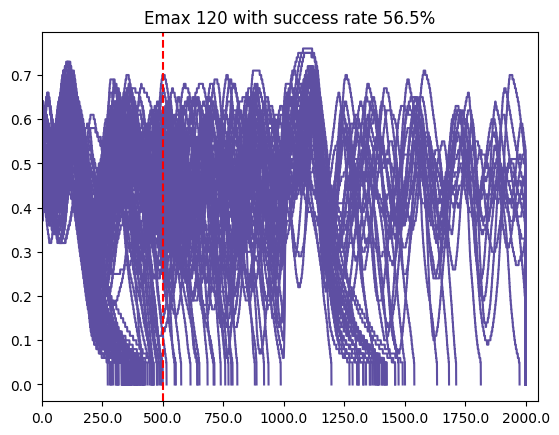

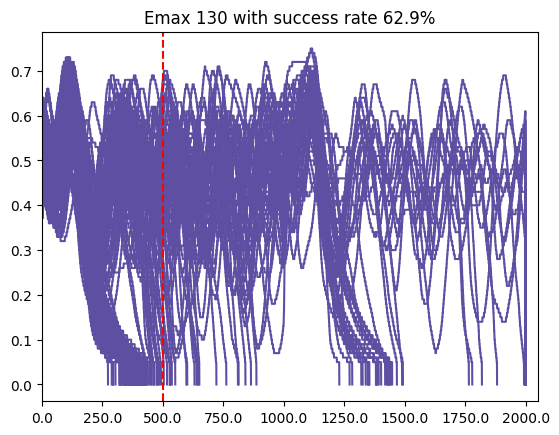

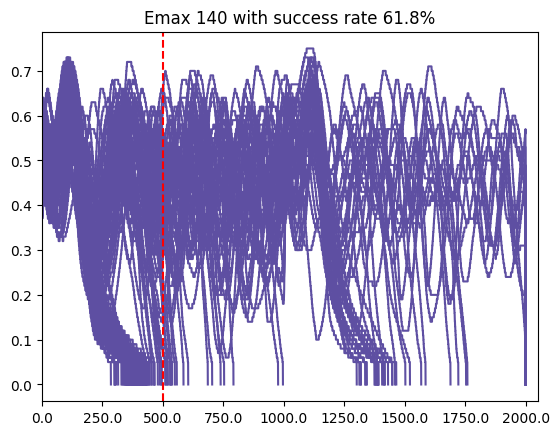

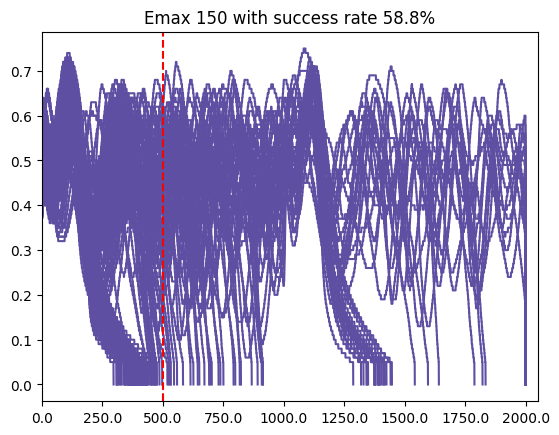

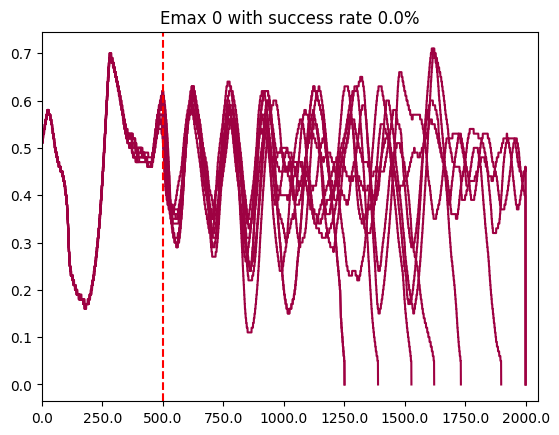

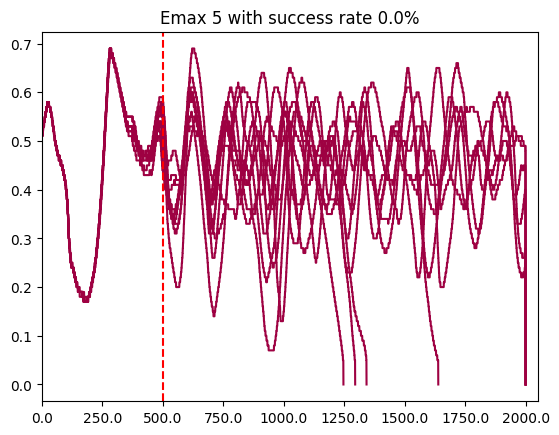

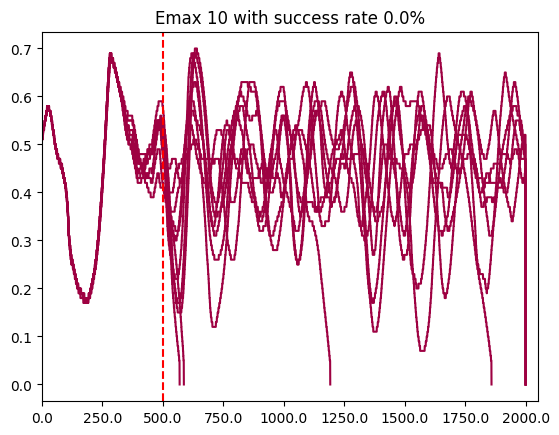

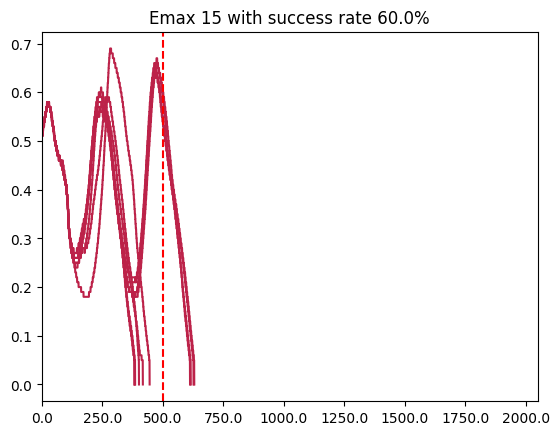

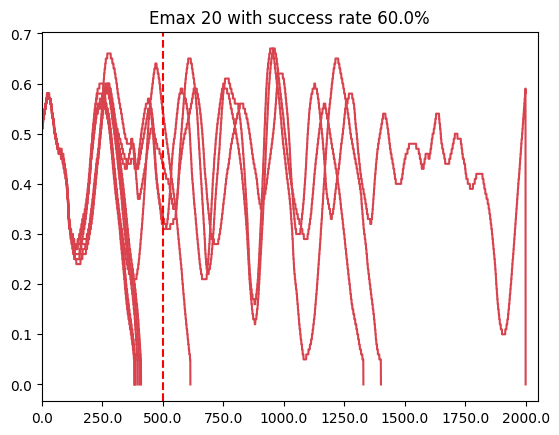

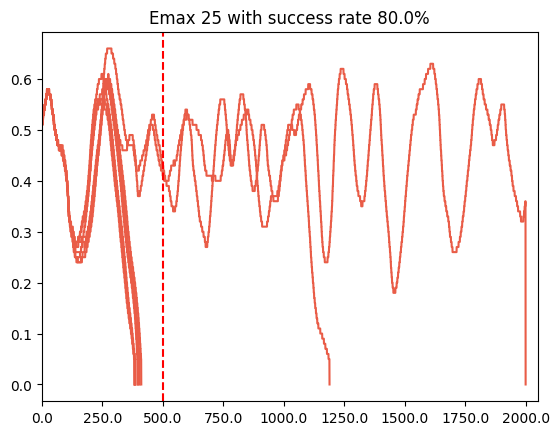

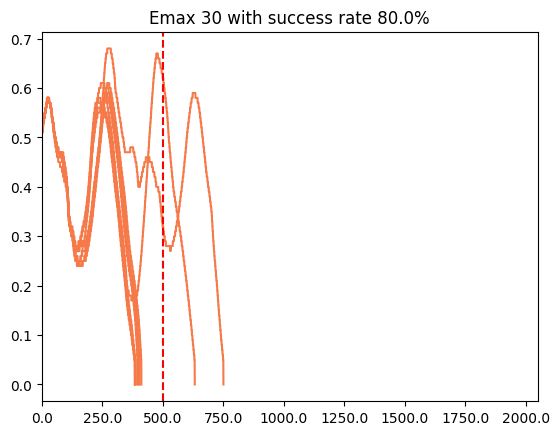

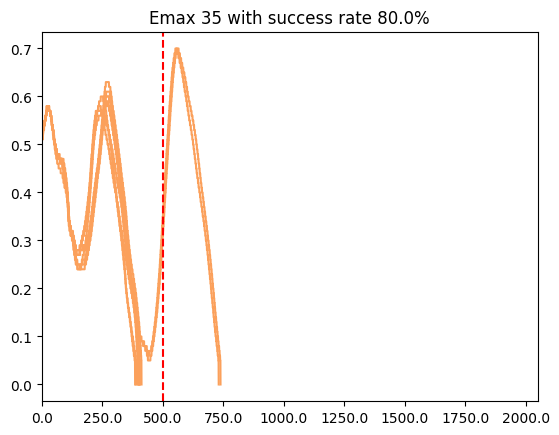

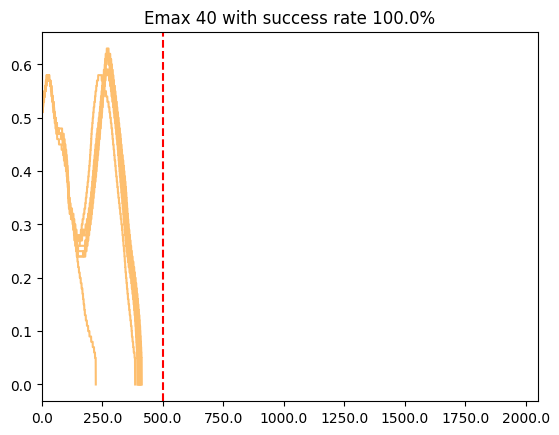

In [ ]:
for mask_idx in range(1,11):
    plt.figure()
    for IC_idx in range(1,21):
        plt.plot(data[IC_idx][mask_idx])
        plt.title(f'MASK {mask_idx}')
        # make sure x range from 0 to 4000
        plt.xlim(0,4100)
        # also make x tick *= 0.5
        plt.xticks(ticks=range(0,4001,500), labels=[str(x*0.5) for x in range(0,4001,500)])

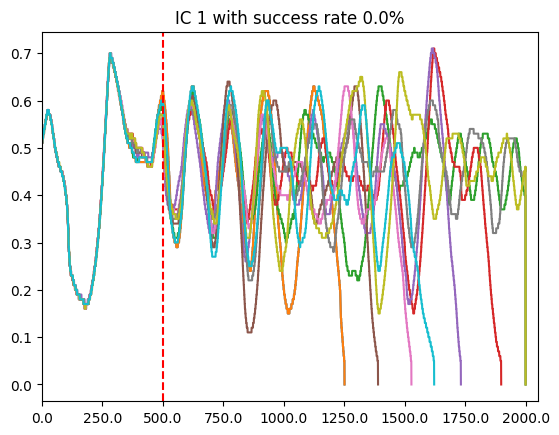

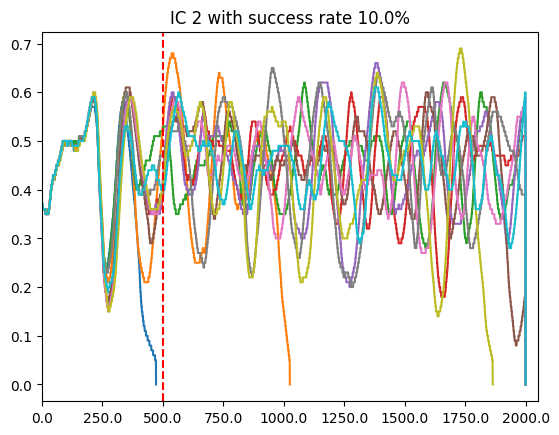

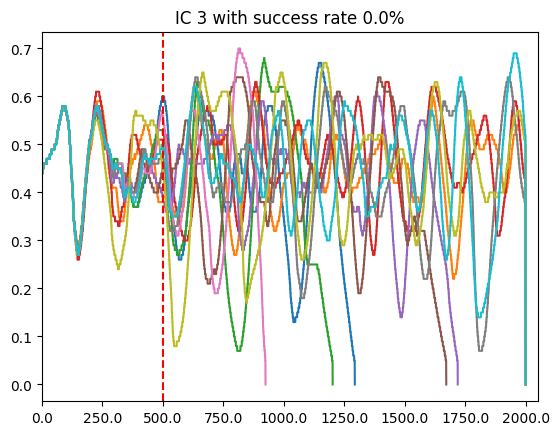

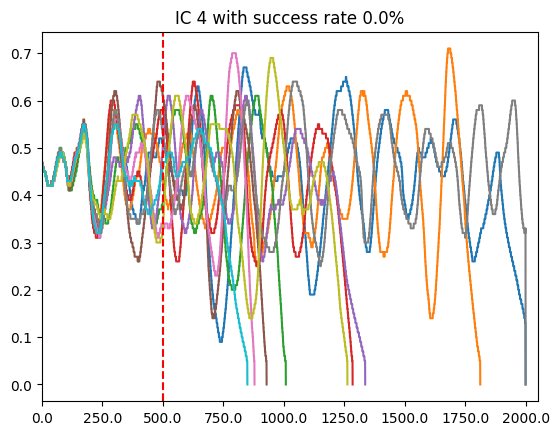

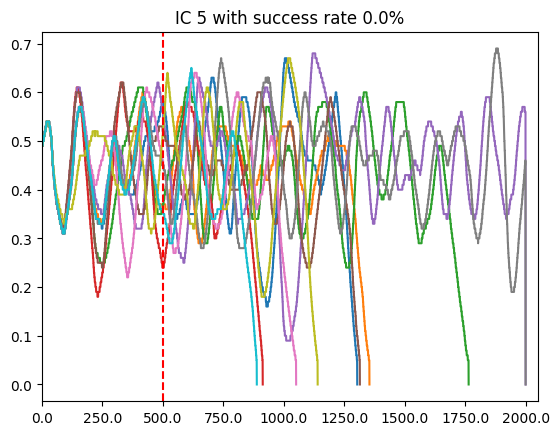

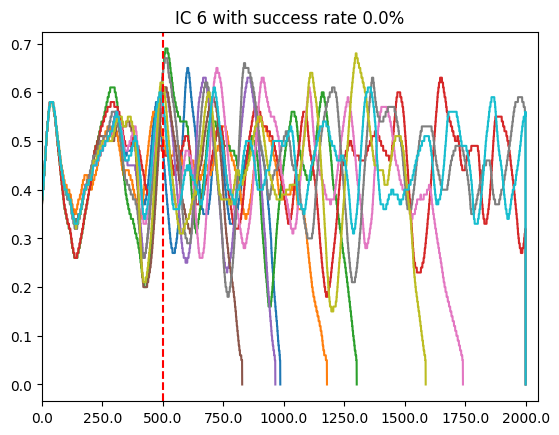

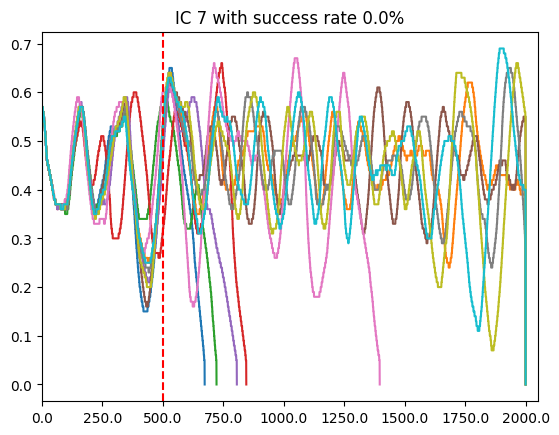

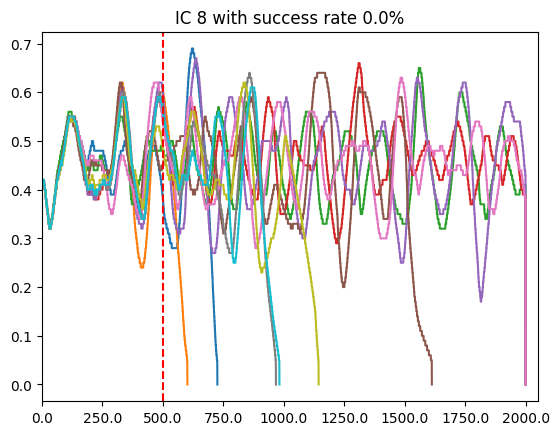

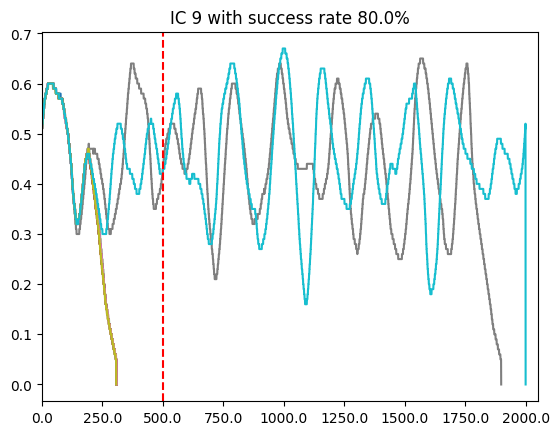

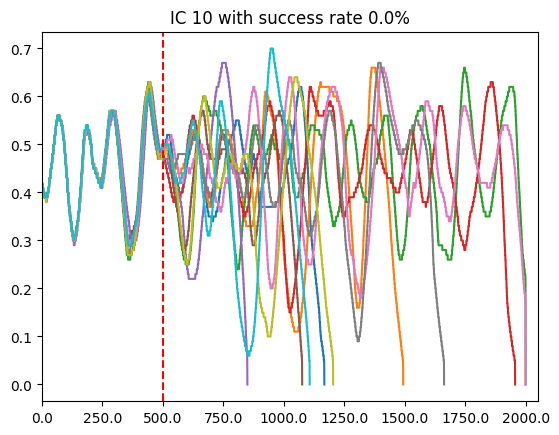

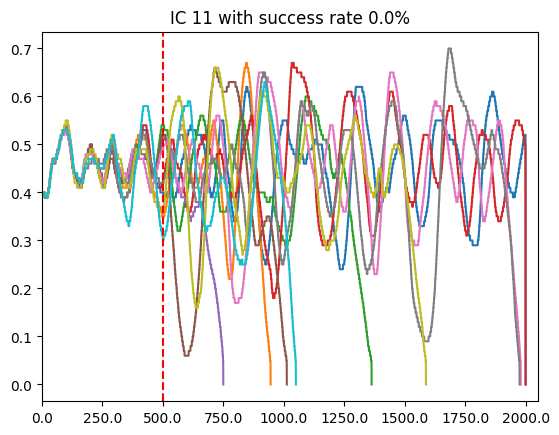

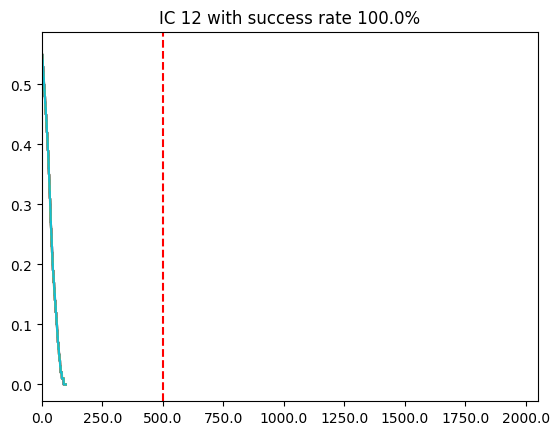

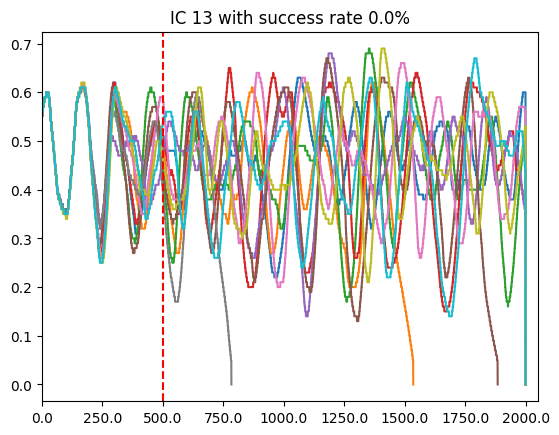

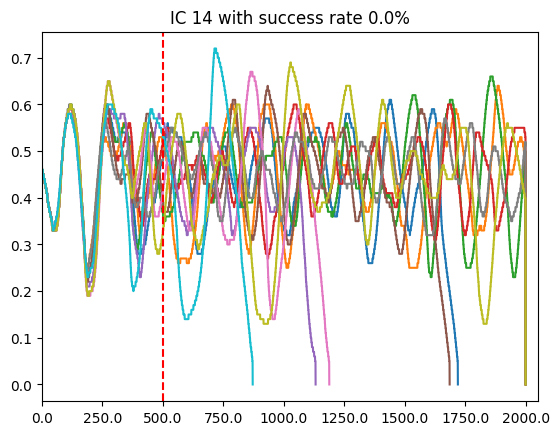

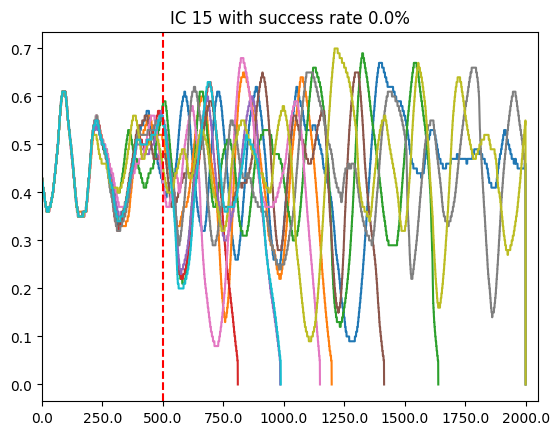

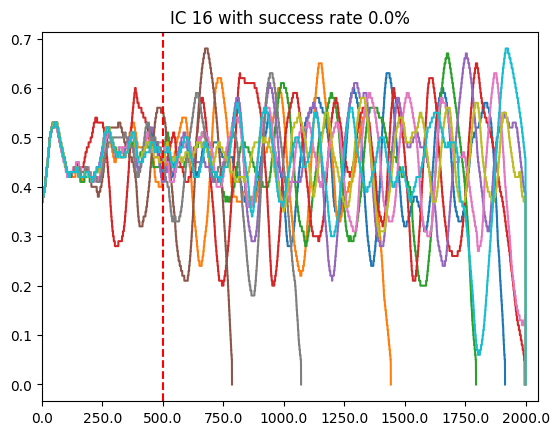

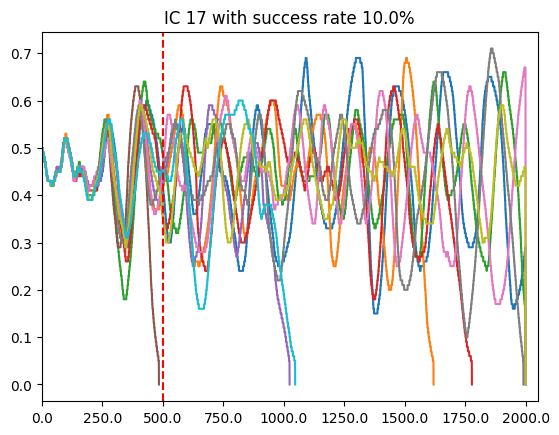

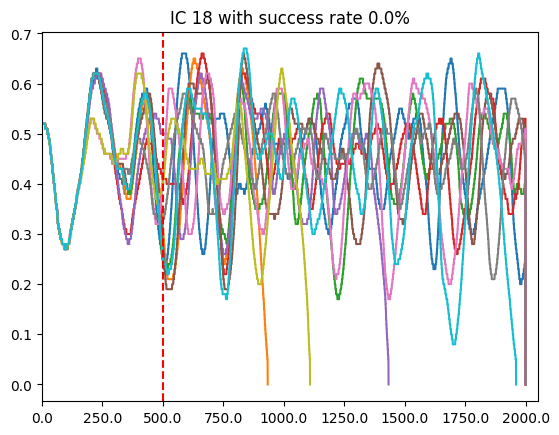

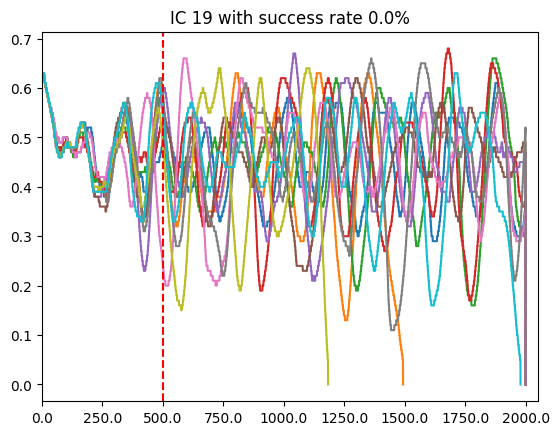

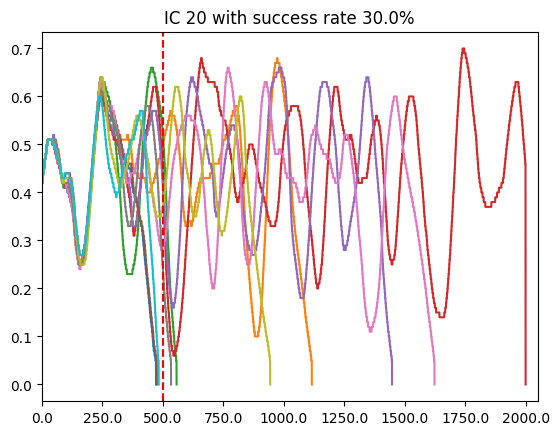

In [66]:

for IC_idx in range(1,21):
    plt.figure()
    success_rate = defaultdict(float)
    for mask_idx in range(1,11):
        success_rate[IC_idx] += 1.0 / 10 if len(data[IC_idx][mask_idx]) <= 500/dt else 0.0
        plt.plot(data[IC_idx][mask_idx])

        # make sure x range from 0 to 4000
        plt.xlim(0,4100)
        # also make x tick *= 0.5
        plt.xticks(ticks=range(0,4001,500), labels=[str(x*0.5) for x in range(0,4001,500)])
    plt.title(f'IC {IC_idx} with success rate {success_rate[IC_idx]*100:.1f}%')
    plt.axvline(x=500/dt, color='r', linestyle='--', label='Success Threshold (500s)')